Zbiór Heart Disease Cleveland


Opis 
Age: Wiek
Sex: Mężczyzna 1, Kobieta 0
cp: Rodzaj bólu: 0 typical angina, 1 atypical angina, 2 non- anginal pain, 3 asymptomatic
trestbps: ciśnienie mm/HG
chol: cholesterol
fbs: Poziom cukru przekraczający 120 mg/dl oznaczenie 1 przeciwnie 0
restecg: Result of electrocardiogram while at rest are represented in 3 distinct values
0 : Normal 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >
0.05 mV) 2: showing probable or definite left ventricular hypertrophyby Estes' criteria (Nominal)
thalach: makssymalne tętno
exang: Angina induced by exercise 0 depicting NO 1 depicting Yes (Nominal)
oldpeak: Exercise induced ST-depression in relative with the state of rest (Numeric)
slope: ST segment measured in terms of slope during peak exercise
0: up sloping; 1: flat; 2: down sloping(Nominal)
ca: The number of major vessels (0–3)(nominal)
thal: A blood disorder called thalassemia
0: NULL 1: normal blood flow 2: fixed defect (no blood flow in some part of the heart) 3: reversible defect (a blood flow is observed but it is not normal(nominal)
target: It is the target variable which we have to predict 1 means patient is suffering from heart disease and 0 means patient is normal.

In [10]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix
from sklearn import preprocessing

In [11]:
df = pd.read_csv("Heart_disease_cleveland_new.csv")
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


In [12]:
#Podział na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(df[["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]], df["target"], test_size=0.2, random_state=42)

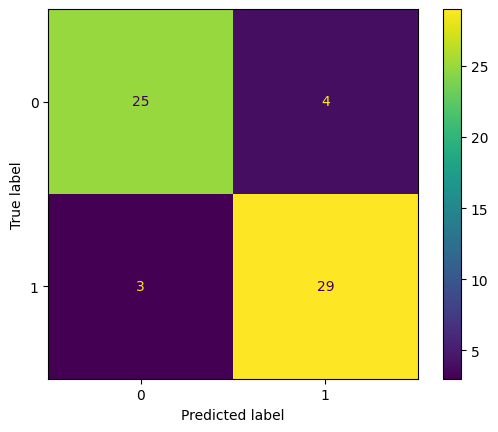

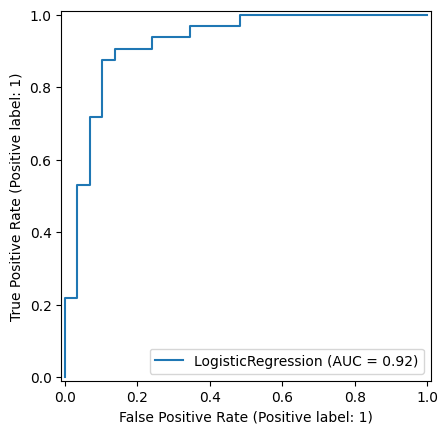

In [13]:
clf = LogisticRegression(random_state=0, max_iter = 1000).fit(X_train, y_train)
y_predicted = clf.predict(X_test)

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
CM = confusion_matrix(y_true = y_test, y_pred = y_predicted)

RocCurveDisplay.from_estimator(clf, X_test, y_test)


In [14]:
precision = CM[0][0] / (CM[0][0] + CM[0][1])
recall = CM[0][0] / (CM[0][0] + CM[1][0])
f1_score = (2 * precision * recall) / (precision + recall)

print(f"precision: {precision}, recall: {recall}, f1 score: {f1_score}")


precision: 0.8620689655172413, recall: 0.8928571428571429, f1 score: 0.8771929824561403


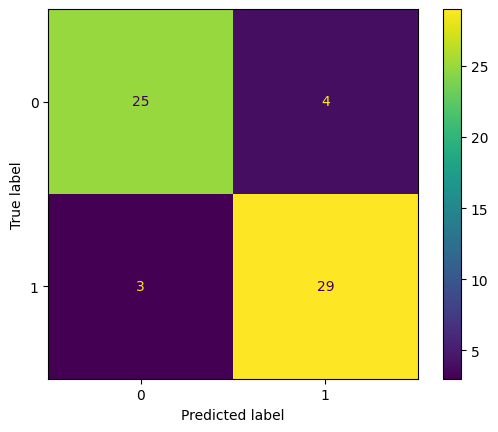

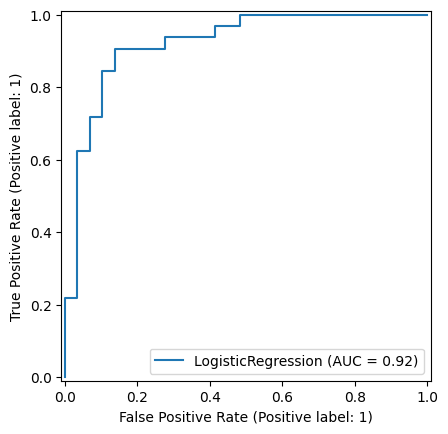

In [15]:
# Standaryzacja
scaler = preprocessing.StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


clf_std = LogisticRegression(random_state=0, max_iter = 1000).fit(X_train_std, y_train)
y_predicted_std = clf_std.predict(X_test_std)

ConfusionMatrixDisplay.from_estimator(clf_std, X_test_std, y_test)
CM = confusion_matrix(y_true = y_test, y_pred = y_predicted_std)

RocCurveDisplay.from_estimator(clf_std, X_test_std, y_test)


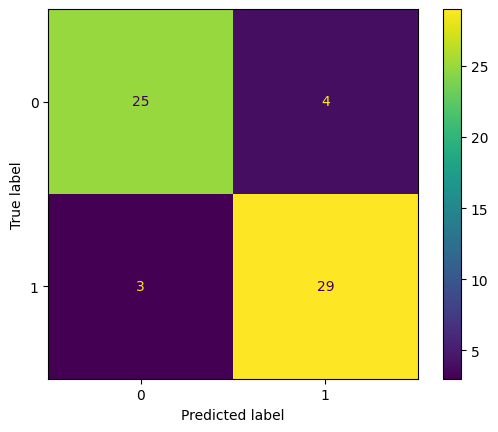

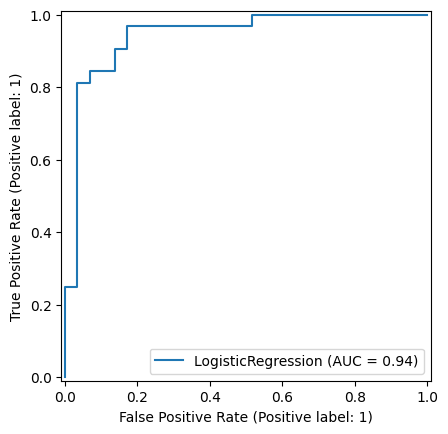

In [16]:
# Normalizacja
scaler = preprocessing.MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)


clf_norm = LogisticRegression(random_state=0, max_iter = 1000).fit(X_train_norm, y_train)
y_predicted_norm = clf_norm.predict(X_test_norm)

ConfusionMatrixDisplay.from_estimator(clf_norm, X_test_norm, y_test)
CM = confusion_matrix(y_true = y_test, y_pred = y_predicted_norm)

RocCurveDisplay.from_estimator(clf_norm, X_test_norm, y_test)


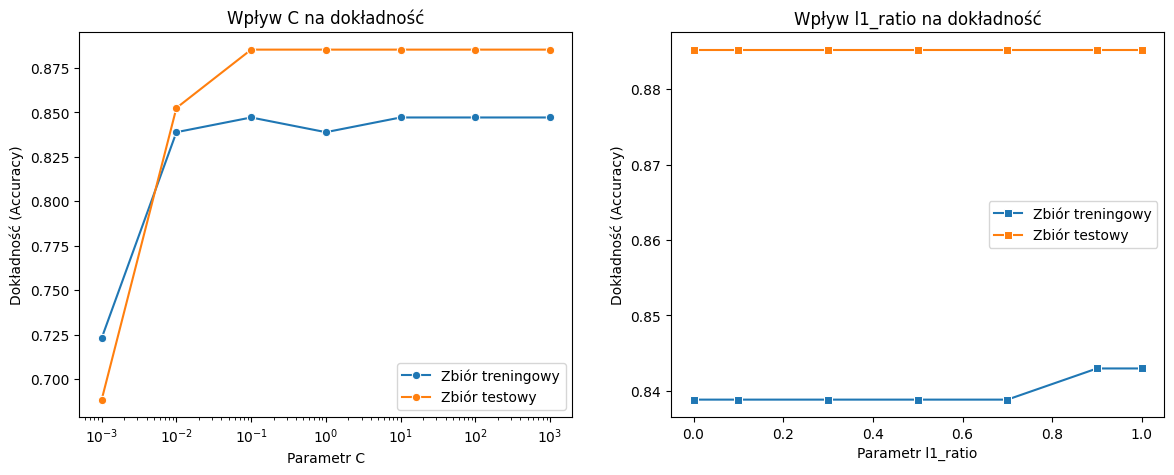

In [17]:
#testy ze względu na C i L1_ratio
l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
l1_scores_train = []
l1_scores_test = []
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
C_scores_train = []
C_scores_test = []

for c in C_values:
    clf_c = LogisticRegression(C=c, random_state=0, max_iter=1000)
    clf_c.fit(X_train_std, y_train)
    train_acc = clf_c.score(X_train_std, y_train)
    test_acc = clf_c.score(X_test_std, y_test)
    C_scores_train.append(train_acc)
    C_scores_test.append(test_acc)

for ratio in l1_ratios:
    clf_l1 = LogisticRegression(random_state=0, solver='saga', l1_ratio=ratio, C=1.0, max_iter =  2500)
    clf_l1.fit(X_train_std, y_train)
    train_acc = clf_l1.score(X_train_std, y_train)
    test_acc = clf_l1.score(X_test_std, y_test)
    l1_scores_train.append(train_acc)
    l1_scores_test.append(test_acc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(x=C_values, y=C_scores_train, marker='o', label='Zbiór treningowy', ax=axes[0])
sns.lineplot(x=C_values, y=C_scores_test, marker='o', label='Zbiór testowy', ax=axes[0])

axes[0].set_xscale('log')
axes[0].set_title('Wpływ C na dokładność')
axes[0].set_xlabel('Parametr C')
axes[0].set_ylabel('Dokładność (Accuracy)')
axes[0].legend()

sns.lineplot(x=l1_ratios, y=l1_scores_train, marker='s', label='Zbiór treningowy', ax=axes[1])
sns.lineplot(x=l1_ratios, y=l1_scores_test, marker='s', label='Zbiór testowy', ax=axes[1])

axes[1].set_title('Wpływ l1_ratio na dokładność')
axes[1].set_xlabel('Parametr l1_ratio')
axes[1].set_ylabel('Dokładność (Accuracy)')
axes[1].legend()
plt.show()

   K-Fold             Typ  Średnia dokładność  Odchylenie std
0       2          Zwykły            0.828359        0.007167
1       2  Stratyfikowany            0.818447        0.010500
2       5          Zwykły            0.838142        0.029130
3       5  Stratyfikowany            0.831585        0.049559
4      10          Zwykły            0.838280        0.054109
5      10  Stratyfikowany            0.834516        0.063840


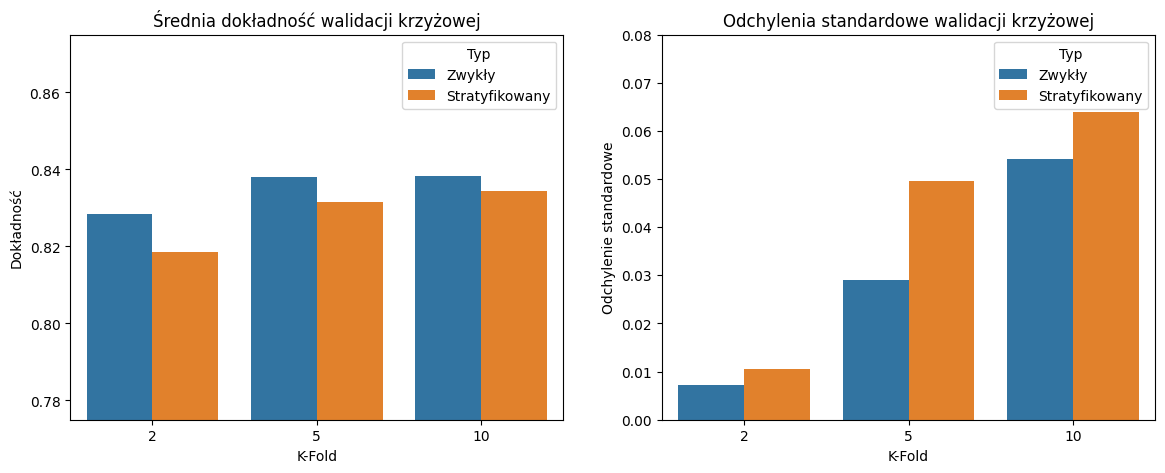

In [18]:
#Zastosowanie walidacji krzyżowej
X_all = df[["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]]
y_all = df['target']

scaler = preprocessing.StandardScaler()
X_all_std = scaler.fit_transform(X_all)

folds = [2, 5, 10]
results = []

clf = LogisticRegression(random_state=0, max_iter=1000)

for k in folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kfold = cross_val_score(clf, X_all_std, y_all, cv=kf, scoring='accuracy')
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_stratified = cross_val_score(clf, X_all_std, y_all, cv=skf, scoring='accuracy')
    
    results.append({
        'K-Fold': k,
        'Typ': 'Zwykły',
        'Średnia dokładność': scores_kfold.mean(),
        'Odchylenie std': scores_kfold.std()
    })
    results.append({
        'K-Fold': k,
        'Typ': 'Stratyfikowany',
        'Średnia dokładność': scores_stratified.mean(),
        'Odchylenie std': scores_stratified.std()
    })

results_df = pd.DataFrame(results)
print(results_df)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='K-Fold', y='Średnia dokładność', hue='Typ', ax=axes[0])
axes[0].set_title("Średnia dokładność walidacji krzyżowej")
axes[0].set_ylim(0.775, 0.875)
axes[0].set_ylabel('Dokładność')

sns.barplot(data=results_df, x='K-Fold', y='Odchylenie std', hue='Typ', ax=axes[1])
axes[1].set_title("Odchylenia standardowe walidacji krzyżowej")
axes[1].set_ylim(0, 0.08)
axes[1].set_ylabel('Odchylenie standardowe')
plt.show()